In [7]:
%load_ext autoreload
%autoreload 2

import torch
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
sys.path.append('../..')

from src import train, utils
from torch.autograd import grad
import src.data.cube_domain as cb
import src.models.expert_chars as ec
import src.models.mlp_model as mm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

L_BOUNDS = (-1.0,)
U_BOUNDS = (1.0,)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cuda


In [8]:
def k(x):
    return torch.where((x > -1/3) & (x < 1/3), 1.0, 10.0).float()

def chi(x):
    return torch.where((x > -1/3) & (x < 1/3), 1.0, 0.0).float()

def res(u, v, x):
    u_x = grad(u, x, torch.ones_like(u), create_graph=True)[0]
    v_x = grad(v, x, torch.ones_like(v), create_graph=True)[0]
    
    res_1 = v + k(x) * u_x
    res_2 = v_x
    
    return res_1, res_2

def loss(model: torch.nn.Module, domain: cb.CubeDomain):
    x = domain.interior.requires_grad_(True)
    out = model(x)
    u, v = out[:, 0], out[:, 1]
    
    res_1, res_2 = res(u, v, x)
    
    loss_1 = torch.mean(res_1**2)
    loss_2 = torch.mean(res_2**2)
    
    return [loss_1, loss_2]


In [ ]:
def g_D(x):
    return 1 - x

def u_0(x):
    return 1 - x**2

# Expert v-model: uses characteristic function to handle discontinuity
model_v_ctx = ec.PerCharCtx(
    input_dim=1,
    output_dim=1,                        # expert 0 → u (scalar), expert 1 → v (scalar)
    hidden_layers_per_output=[
        [16, 16, 16],                          # hidden widths for u-expert
        [16, 16, 16],                          # hidden widths for v-expert
    ],
    char_functions=[lambda x : 1 - chi(x) ,chi],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
)

# Naive v-model: plain MLP with no discontinuity awareness
model_v_naive_ctx = mm.ModelContext(
    input_dim=1,
    output_dim=1,
    layer=[32, 32, 32],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
)

model_u_ctx = mm.ModelContext(
    input_dim=1,
    output_dim=1,
    layer=[32, 32, 32],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce=True,
    constraint_functions=(g_D, u_0)
)

model_v       = ec.PerCharModel(model_v_ctx).to(device)
model_u       = mm.MLPModel(model_u_ctx).to(device)

model_v_naive = mm.MLPModel(model_v_naive_ctx).to(device)
model_u_naive = mm.MLPModel(model_u_ctx).to(device)

model_combined       = ec.MultiModel(model_u, model_v)
model_combined_naive = ec.MultiModel(model_u_naive, model_v_naive)


In [10]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=1,
    N_int=5_000,
    N_sides=[(0, 0)],
    device=device,
    time_dependant=False,
)

domain = cb.CubeDomain(domain_ctx)
print(f"Interior points: {domain.interior.shape}")

Interior points: torch.Size([5000, 1])


In [11]:
optim_combined       = torch.optim.Adam(model_combined.parameters(), lr=1e-4)
optim_combined_naive = torch.optim.Adam(model_combined_naive.parameters(), lr=1e-4)

scheduler_combined       = ReduceLROnPlateau(optim_combined,       factor=0.5, patience=300)
scheduler_combined_naive = ReduceLROnPlateau(optim_combined_naive, factor=0.5, patience=300)

# Deep-copy initial weights for post-training comparison
model_init       = copy.deepcopy(model_combined)
model_init_naive = copy.deepcopy(model_combined_naive)
print("Initial checkpoints saved.")

Initial checkpoints saved.


In [12]:
train_ctx = train.TrainingContext(
    model=model_combined,
    domain=domain,
    optimizer=optim_combined,
    loss_fn=loss,
    epochs=10_000,
    monitor_gradient=True,
    monitor_lr=True,
)

pde_loss, pde_loss_comp = train.train_switch_to_lbfgs(train_ctx, lbfgs_lr=0.1)

train_ctx_naive = train.TrainingContext(
    model=model_combined_naive,
    domain=domain,
    optimizer=optim_combined_naive,
    loss_fn=loss,
    epochs=10_000,
    monitor_gradient=True,
    monitor_lr=True,
)

pde_loss_naive, pde_loss_comp_naive = train.train_switch_to_lbfgs(train_ctx_naive, lbfgs_lr=0.1)


Loss at epoch 1 is: 65.77298736572266. Total gradient norm: nan Current learing rate: 0.0001 
Loss at epoch 100 is: 49.95320510864258. Total gradient norm: 42.09004696087611 Current learing rate: 0.0001 
Loss at epoch 200 is: 43.041996002197266. Total gradient norm: 16.889386467598154 Current learing rate: 0.0001 
Loss at epoch 300 is: 38.64664077758789. Total gradient norm: 31.774450788213457 Current learing rate: 0.0001 
Loss at epoch 400 is: 20.861133575439453. Total gradient norm: 50.93902864435412 Current learing rate: 0.0001 
Loss at epoch 500 is: 7.947556018829346. Total gradient norm: 33.952398725183 Current learing rate: 0.0001 
Loss at epoch 600 is: 4.381413459777832. Total gradient norm: 11.992024897923647 Current learing rate: 0.0001 
Loss at epoch 700 is: 3.9424173831939697. Total gradient norm: 2.720213586804476 Current learing rate: 0.0001 
Loss at epoch 800 is: 3.9101874828338623. Total gradient norm: 1.3832829052709006 Current learing rate: 0.0001 
Loss at epoch 900 is

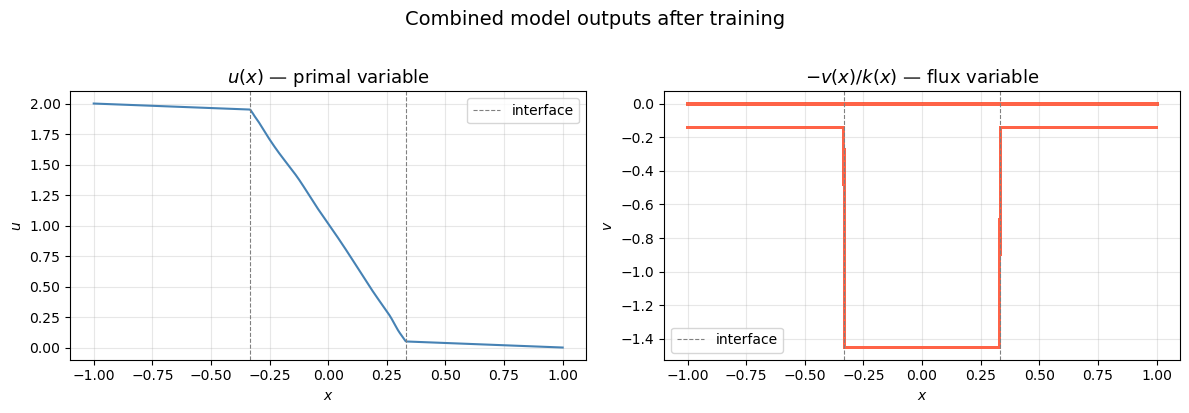

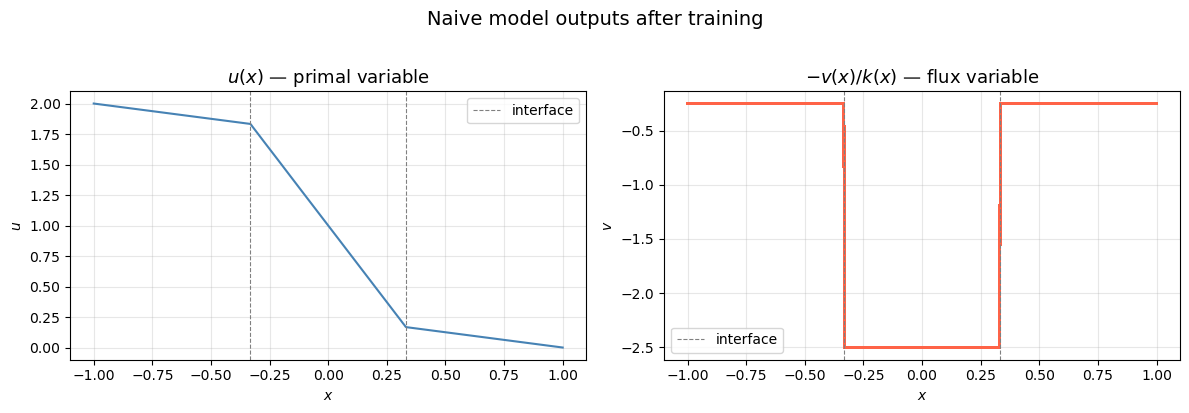

In [13]:

import matplotlib.pyplot as plt
import numpy as np


def plot_uv(
    model: torch.nn.Module,
    l_bounds: tuple[float, ...],
    u_bounds: tuple[float, ...],
    title: str,
    n_points: int = 1_000,
    device: torch.device = torch.device("cpu"),
) -> None:
    """Plot the u and v outputs of a combined model over the 1-D domain.

    Args:
        model: Trained model returning [u, v] along axis-1.
        l_bounds: Lower bounds of the domain (length-1 tuple for 1-D).
        u_bounds: Upper bounds of the domain (length-1 tuple for 1-D).
        n_points: Number of evaluation points.
        device: Torch device used for inference.
    """
    x_np = np.linspace(l_bounds[0], u_bounds[0], n_points)
    x_t = torch.tensor(x_np, dtype=torch.float32, device=device).unsqueeze(1)

    model.eval()
    with torch.no_grad():
        out = model(x_t)          # shape: (n_points, 2)
    u_np = out[:, 0].cpu().numpy()
    v_np = torch.div(- out[:, 1], k(x_t)).cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(x_np, u_np, color="steelblue", linewidth=1.5)
    axes[0].set_title("$u(x)$ — primal variable", fontsize=13)
    axes[0].set_xlabel("$x$")
    axes[0].set_ylabel("$u$")
    axes[0].axvline(1 / 3, color="gray", linestyle="--", linewidth=0.8, label="interface")
    axes[0].axvline(-1 / 3, color="gray", linestyle="--", linewidth=0.8)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x_np, v_np, color="tomato", linewidth=1.5)
    axes[1].set_title("$-v(x)/k(x)$ — flux variable", fontsize=13)
    axes[1].set_xlabel("$x$")
    axes[1].set_ylabel("$v$")
    axes[1].axvline(1 / 3, color="gray", linestyle="--", linewidth=0.8, label="interface")
    axes[1].axvline(-1 / 3, color="gray", linestyle="--", linewidth=0.8)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_uv(model_combined, L_BOUNDS, U_BOUNDS, title="Combined model outputs after training" ,device=device)
plot_uv(model_combined_naive, L_BOUNDS, U_BOUNDS, title="Naive model outputs after training",device=device)


In [17]:
x = domain.interior.requires_grad_(True)
out_chars = model_combined(x)
u_chars, v_chars = out_chars[:, 0], out_chars[:, 1]

res_1_chars, res_2_chars = res(u_chars, v_chars, x)

out_naive = model_combined_naive(x)
u_naive, v_naive = out_naive[:, 0], out_naive[:, 1]

res_1_naive, res_2_naive = res(u_naive, v_naive, x)

l2_res_1_chars = torch.sqrt(torch.mean(res_1_chars**2)).item()
l2_res_2_chars = torch.sqrt(torch.mean(res_2_chars**2)).item()

l2_res_1_naive = torch.sqrt(torch.mean(res_1_naive**2)).item()
l2_res_2_naive = torch.sqrt(torch.mean(res_2_naive**2)).item()

print(f"L2 chars ||v + k·u_x|| = {l2_res_1_chars:.6e}")
print(f"L2 chars ||v_x||       = {l2_res_2_chars:.6e}")
print()
print(f"L2 naive ||v + k·u_x|| = {l2_res_1_naive:.6e}")
print(f"L2 naive ||v_x||       = {l2_res_2_naive:.6e}")


L2 chars ||v + k·u_x|| = 1.547751e+00
L2 chars ||v_x||       = 2.371562e-04

L2 naive ||v + k·u_x|| = 1.086885e-01
L2 naive ||v_x||       = 2.600219e-03


In [15]:
def max_param_drift(model: torch.nn.Module, init_model: torch.nn.Module) -> float:
    learned = model.state_dict()
    initial = init_model.state_dict()
    return max(
        (learned[k].float() - initial[k].float()).abs().max().item()
        for k in learned
    )

drift_expert = max_param_drift(model_combined, model_init)
drift_naive  = max_param_drift(model_combined_naive, model_init_naive)

print(f"Max |Δ param|  char: {drift_expert:.6e}")
print(f"Max |Δ param|  naive:  {drift_naive:.6e}")


Max |Δ param|  char: 1.354710e+00
Max |Δ param|  naive:  1.540173e+00


/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


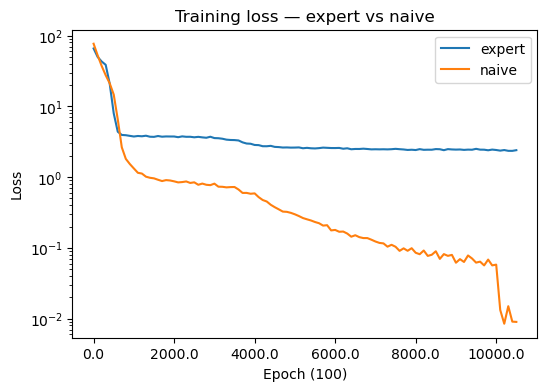

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


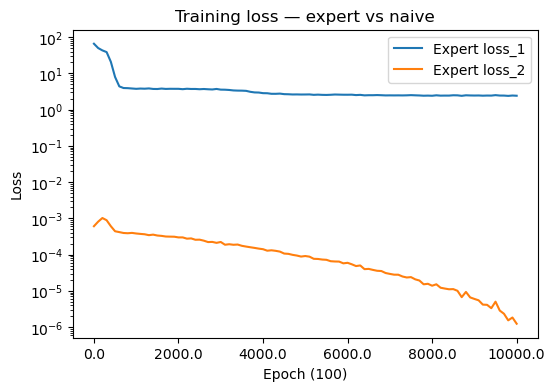

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


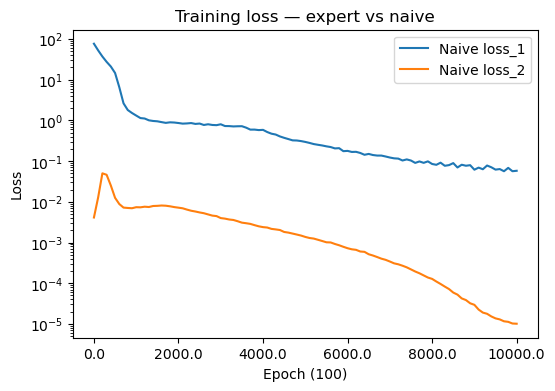

In [16]:
loss_plot_ctx = utils.PlotContext(
    x_label="Epoch (100)",
    y_label="Loss",
    titles=["Training loss — expert vs naive"],
)

utils.plot_loss_values(
    {"expert": pde_loss, "naive": pde_loss_naive},
    loss_plot_ctx,
)

titles=["Training loss — expert componentwise"],
utils.plot_loss_values(
    {"Expert loss_1": pde_loss_comp[0], "Expert loss_2": pde_loss_comp[1]},
    loss_plot_ctx,
)

titles=["Training loss — naive componentwise"],
utils.plot_loss_values(
    {"Naive loss_1": pde_loss_comp_naive[0], "Naive loss_2": pde_loss_comp_naive[1]},
    loss_plot_ctx,
)

